# 01 — Data Foundation and Engineering

**Project:** Transaction Intelligence: Customer Segmentation and Behavioral Analytics  
**Dataset:** Berka / PKDD'99 Financial Dataset  
**Course alignment:**

- **Week 1 — Data Science in Practice**
- **Week 3 — Data Preparation**
- **Week 4 — Data Engineering**
- **Week 5 — Modern Data Architectures**

This notebook establishes the analytical contract for the project and builds its reusable data foundation. It frames the problem, audits the validated relational snapshot, documents preparation decisions, and produces four Silver-layer Parquet tables. It does **not** perform customer segmentation or make fraud claims.

## Notebook objectives

1. Frame the business and analytical problem.
2. Verify provenance, schema, keys, relationships, and data quality.
3. Standardize important categorical fields without erasing the source values.
4. Define defensible missing-value, extreme-value, encoding, scaling, and leakage policies.
5. Build purpose-specific analytical tables using DuckDB SQL.
6. Document how the local implementation maps to modern data architectures.


## 1. Business-problem framing

### Primary research question

> How can historical banking transactions and customer characteristics be used to identify meaningful customer segments and understand differences in financial behavior?

### Supporting questions

- What transaction, balance, service-use, and account-tenure behaviors are present?
- Which characteristics distinguish groups of accounts?
- How do service relationships, demographics, and activity patterns differ across groups?
- Which accounts behave unusually relative to comparable accounts?
- What organizational activity can be forecast, and what service recommendations could be investigated?
- How sensitive are the findings to preparation choices, historical context, and incomplete information?

The project is an exploratory customer-intelligence study. A statistical outlier is not evidence of fraud, and a discovered association is not evidence that a recommendation will benefit a customer.


### Stakeholders, decisions, and outputs

| Stakeholder | Potential decision or need | Appropriate project output |
|---|---|---|
| Customer analytics team | Understand heterogeneous account behavior | Interpretable behavioral segments |
| Product and service team | Investigate relevant service combinations | Association patterns and recommendation hypotheses |
| Branch or portfolio managers | Monitor changes in aggregate banking activity | Descriptive summaries and bounded forecasts |
| Data and AI team | Reproduce, validate, and extend the analysis | Versioned data pipeline, quality checks, and documented features |
| Customers and regulators | Expect fair and responsible use of financial data | Privacy protection, limitations, and non-discriminatory interpretation |

No automated lending, fraud, or customer-treatment decision should be made from this course project.


### Analytics framing

| Analytics type | Project question | Planned method |
|---|---|---|
| **Descriptive** | What behaviors are present? | EDA, summaries, temporal profiles |
| **Diagnostic** | What characteristics distinguish customer groups? | Feature comparisons, clustering profiles |
| **Predictive** | What aggregate banking activity or bounded loan outcome can be estimated? | Time-series forecasting; limited supervised case study |
| **Prescriptive** | What service recommendations could be investigated? | Association rules interpreted as hypotheses |

The descriptive and diagnostic components are central. Predictive and prescriptive components remain bounded demonstrations because the project goal is not to build another fraud or lending-decision tool.


### Analytical units and grain

| Unit | Grain | Intended use |
|---|---|---|
| Transaction | One row per transaction | Cash-flow, temporal, and behavioral analysis |
| Disposition | One client–account relationship | Ownership and authorized-user analysis |
| Account | One row per bank account | Primary unit for segmentation |
| Loan | One row per loan | Bounded supervised-learning case study |
| District | One row per district | Contextual demographic attributes |
| Month | One row per calendar month | Aggregate time-series analysis |

An account is the primary segmentation unit because transactions and most services are linked to accounts. Every account has exactly one OWNER disposition; 869 accounts also have a DISPONENT. Treating every disposition as a separate account would duplicate shared financial behavior.


### Success criteria and lifecycle

**Analytical success**

- Produce exactly one validated account-level base record for each of the 4,500 accounts.
- Preserve all 1,056,320 source transactions after standardization.
- Explain segment differences with stable, interpretable features—not only cluster metrics.
- Distinguish data errors, valid extremes, and behavioral outliers.
- Prevent temporal leakage in forecasting and loan-outcome analysis.
- State historical, privacy, representation, and causal limitations.

**Lifecycle**

Problem framing → acquisition → validation → preparation → exploration → feature engineering → modelling → evaluation → interpretation → reporting.

Each notebook consumes versioned outputs from the previous stage. Raw files are immutable; derived tables can be rebuilt.


### Ethical constraints

- The dataset is anonymized, but banking behavior remains sensitive.
- Gender, age, and district attributes require a documented analytical purpose and bias assessment.
- The data describe a Czech bank in 1993–1998; findings are not automatically transferable to present-day customers or other countries.
- Segment labels must describe observed behavior without stigmatizing customers.
- Behavioral outliers must not be described as fraud or misconduct.
- Recommendation patterns are hypotheses, not proof of customer need or suitability.
- Loan-outcome analysis must exclude information recorded after the loan decision date.


## 2. Reproducible environment and provenance

The acquisition process creates an immutable Bronze snapshot: eight CSV tables, the original MariaDB DDL, and a checksum manifest. The local DuckDB database reconstructs the keys and relationships and is the only database queried by this notebook.


In [1]:
from pathlib import Path
import json
import platform

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import FancyBboxPatch
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing pyproject.toml")


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MANIFEST_PATH = RAW_DIR / "download_manifest.json"
RELATIONSHIP_REPORT_PATH = INTERIM_DIR / "relationship_validation.json"
DATABASE_PATH = INTERIM_DIR / "berka.duckdb"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)

environment = pd.Series(
    {
        "Python": platform.python_version(),
        "DuckDB": duckdb.__version__,
        "Project root": ".",
        "Database": str(DATABASE_PATH.relative_to(PROJECT_ROOT)),
    },
    name="value",
)
display(environment.to_frame())


Matplotlib is building the font cache; this may take a moment.


,value
Python,3.14.6
DuckDB,1.5.5
Project root,.
Database,data/interim/berka.duckdb


In [2]:
required_artifacts = {
    "Download manifest": MANIFEST_PATH,
    "Source MariaDB schema": RAW_DIR / "schema_mariadb.sql",
    "Local DuckDB database": DATABASE_PATH,
    "Relationship validation": RELATIONSHIP_REPORT_PATH,
}

artifact_status = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "exists": path.is_file(),
            "size_mb": round(path.stat().st_size / 1_048_576, 3) if path.is_file() else None,
        }
        for name, path in required_artifacts.items()
    ]
)
display(artifact_status)

missing_artifacts = artifact_status.loc[~artifact_status["exists"], "artifact"].tolist()
assert not missing_artifacts, (
    "Missing required artifacts: "
    + ", ".join(missing_artifacts)
    + ". Run scripts/download_berka.py and scripts/build_local_database.py first."
)

manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
relationship_report = json.loads(RELATIONSHIP_REPORT_PATH.read_text(encoding="utf-8"))

provenance = pd.Series(
    {
        "Source": manifest["source"],
        "Dataset": manifest["dataset"],
        "URL": manifest["url"],
        "Retrieved (UTC)": manifest["retrieved_at_utc"],
        "Source database": manifest["database"],
        "Source host": manifest["host"],
        "Schema checksum": manifest["schema_sha256"],
        "Relationship validation": relationship_report["valid"],
    },
    name="value",
)
display(provenance.to_frame())


,artifact,path,exists,size_mb
0,Download manifest,data/raw/download_manifest.json,True,0.012
1,Source MariaDB schema,data/raw/schema_mariadb.sql,True,0.004
2,Local DuckDB database,data/interim/berka.duckdb,True,46.262
3,Relationship validation,data/interim/relationship_validation.json,True,0.002


,value
Source,CTU Prague Relational Dataset Repository
Dataset,Financial — PKDD’99 Financial Dataset
URL,https://relational.fel.cvut.cz/dataset/Financial
Retrieved (UTC),2026-07-17T05:45:37.075352+00:00
Source database,financial
Source host,relational.fel.cvut.cz
Schema checksum,ba5ea18fe037f77ccb97ef98a0cb91d5ca50838c44375d...
Relationship validation,True


## 3. Relational inventory and data engineering

The database contains eight normalized tables. Primary and foreign keys are retained in DuckDB, while the download manifest preserves the original MariaDB column definitions and checksums.

### Relationship map

    district ──< account ──< disp >── client >── district
                     │          │
                     │          └──< card
                     ├──< loan
                     ├──< order
                     └──< trans

The disposition table resolves the many-to-many relationship between clients and accounts. Purpose-specific joins are used instead of creating one universal denormalized table with mixed grain.


In [3]:
connection = duckdb.connect(str(DATABASE_PATH), read_only=True)

inventory_rows = []
for table_name, metadata in manifest["tables"].items():
    local_rows = connection.execute(
        "SELECT COUNT(*) FROM " + '"' + table_name.replace('"', '""') + '"'
    ).fetchone()[0]
    inventory_rows.append(
        {
            "table": table_name,
            "grain/key": ", ".join(metadata["primary_key"]),
            "columns": len(metadata["columns"]),
            "source_rows": metadata["source_row_count"],
            "exported_rows": metadata["exported_row_count"],
            "local_rows": local_rows,
            "foreign_keys": len(metadata["foreign_keys"]),
            "row_counts_match": (
                metadata["source_row_count"] == metadata["exported_row_count"] == local_rows
            ),
        }
    )

table_inventory = pd.DataFrame(inventory_rows).sort_values("table").reset_index(drop=True)
display(table_inventory)
assert table_inventory["row_counts_match"].all()

relationship_summary = pd.DataFrame(relationship_report["relationships"])
display(
    relationship_summary[
        ["table", "columns", "referenced_table", "referenced_columns", "orphan_count", "valid"]
    ]
)
assert relationship_report["valid"]
assert relationship_summary["valid"].all()


,table,grain/key,columns,source_rows,exported_rows,local_rows,foreign_keys,row_counts_match
0,account,account_id,4,4500,4500,4500,1,True
1,card,card_id,4,892,892,892,1,True
2,client,client_id,4,5369,5369,5369,1,True
3,disp,disp_id,4,5369,5369,5369,2,True
4,district,district_id,16,77,77,77,0,True
5,loan,loan_id,7,682,682,682,1,True
6,order,order_id,6,6471,6471,6471,1,True
7,trans,trans_id,10,1056320,1056320,1056320,1,True


,table,columns,referenced_table,referenced_columns,orphan_count,valid
0,account,[district_id],district,[district_id],0,True
1,card,[disp_id],disp,[disp_id],0,True
2,client,[district_id],district,[district_id],0,True
3,disp,[account_id],account,[account_id],0,True
4,disp,[client_id],client,[client_id],0,True
5,loan,[account_id],account,[account_id],0,True
6,order,[account_id],account,[account_id],0,True
7,trans,[account_id],account,[account_id],0,True


### ETL and lineage

1. **Extract:** stream the public CTU MariaDB tables into immutable CSV files.
2. **Validate:** compare exact source/export row counts and record checksums and source DDL.
3. **Load:** reconstruct typed DuckDB tables with primary and foreign keys.
4. **Transform:** create purpose-specific Silver Parquet tables in this notebook.
5. **Curate:** create Gold customer features, segment assignments, and presentation tables later.

The raw snapshot is never modified. Every Silver output below is derived from the validated DuckDB database and can be reproduced by rerunning this notebook.


## 4. Data-quality baseline

Data quality is assessed before changing values. Missingness is interpreted in context: a null counterparty bank may be structurally correct for a cash transaction, while a missing district statistic is an incomplete observation.

Primary-key duplication and referential integrity are hard failures. Context-dependent missing values and valid extremes are documented rather than removed automatically.


In [4]:
quality_rows = []

for table_name, metadata in manifest["tables"].items():
    quoted_table = '"' + table_name.replace('"', '""') + '"'
    primary_key = metadata["primary_key"]
    pk_columns = ", ".join('"' + column.replace('"', '""') + '"' for column in primary_key)

    duplicate_pk_count = connection.execute(
        "SELECT COUNT(*) FROM ("
        + "SELECT "
        + pk_columns
        + ", COUNT(*) AS n FROM "
        + quoted_table
        + " GROUP BY "
        + pk_columns
        + " HAVING COUNT(*) > 1)"
    ).fetchone()[0]

    null_pk_condition = " OR ".join(
        '"' + column.replace('"', '""') + '" IS NULL' for column in primary_key
    )
    null_pk_count = connection.execute(
        "SELECT COUNT(*) FROM " + quoted_table + " WHERE " + null_pk_condition
    ).fetchone()[0]

    for column in metadata["columns"]:
        quoted_column = '"' + column["name"].replace('"', '""') + '"'
        missing_count = connection.execute(
            "SELECT COUNT(*) FILTER (WHERE "
            + quoted_column
            + " IS NULL) FROM "
            + quoted_table
        ).fetchone()[0]
        if missing_count:
            quality_rows.append(
                {
                    "table": table_name,
                    "column": column["name"],
                    "missing_count": missing_count,
                    "missing_pct": 100 * missing_count / metadata["source_row_count"],
                }
            )

    assert duplicate_pk_count == 0, table_name + " contains duplicate primary keys"
    assert null_pk_count == 0, table_name + " contains null primary keys"

missingness = pd.DataFrame(quality_rows).sort_values(
    ["missing_pct", "table"], ascending=[False, True]
)
display(missingness.style.format({"missing_pct": "{:.2f}%"}))


,table,column,missing_count,missing_pct
4,trans,bank,782812,74.11%
5,trans,account,760931,72.04%
3,trans,k_symbol,481881,45.62%
2,trans,operation,183114,17.34%
0,district,A12,1,1.30%
1,district,A15,1,1.30%


In [5]:
categorical_queries = {
    "account.frequency": "SELECT frequency AS value, COUNT(*) AS rows FROM account GROUP BY 1 ORDER BY 2 DESC",
    "disp.type": "SELECT type AS value, COUNT(*) AS rows FROM disp GROUP BY 1 ORDER BY 2 DESC",
    "card.type": "SELECT type AS value, COUNT(*) AS rows FROM card GROUP BY 1 ORDER BY 2 DESC",
    "loan.status": "SELECT status AS value, COUNT(*) AS rows FROM loan GROUP BY 1 ORDER BY 1",
    "trans.type": "SELECT type AS value, COUNT(*) AS rows FROM trans GROUP BY 1 ORDER BY 2 DESC",
    "trans.operation": "SELECT COALESCE(operation, '<NULL>') AS value, COUNT(*) AS rows FROM trans GROUP BY 1 ORDER BY 2 DESC",
    "trans.k_symbol": "SELECT COALESCE(NULLIF(TRIM(k_symbol), ''), '<UNSPECIFIED>') AS value, COUNT(*) AS rows FROM trans GROUP BY 1 ORDER BY 2 DESC",
}

categorical_profiles = []
for field, query in categorical_queries.items():
    profile = connection.execute(query).fetchdf()
    profile.insert(0, "field", field)
    categorical_profiles.append(profile)

display(pd.concat(categorical_profiles, ignore_index=True))

date_coverage = connection.execute(
    """
    SELECT 'account' AS table_name, MIN(date) AS first_date, MAX(date) AS last_date
    FROM account
    UNION ALL
    SELECT 'card', MIN(issued), MAX(issued) FROM card
    UNION ALL
    SELECT 'loan', MIN(date), MAX(date) FROM loan
    UNION ALL
    SELECT 'trans', MIN(date), MAX(date) FROM trans
    """
).fetchdf()
display(date_coverage)


,field,value,rows
0,account.frequency,POPLATEK MESICNE,4167
1,account.frequency,POPLATEK TYDNE,240
2,account.frequency,POPLATEK PO OBRATU,93
3,disp.type,OWNER,4500
4,disp.type,DISPONENT,869
5,card.type,classic,659
6,card.type,junior,145
7,card.type,gold,88
8,loan.status,A,203
9,loan.status,B,31


,table_name,first_date,last_date
0,account,1993-01-01,1997-12-29
1,card,1993-11-07,1998-12-29
2,loan,1993-07-05,1998-12-08
3,trans,1993-01-01,1998-12-31


### Preparation decisions

**Missing values**

- Transaction operation, purpose, bank, and counterparty account are often structurally absent. They remain null in the clean table; a separate standardized purpose label uses “unspecified” for analysis.
- District A12 and A15 each have one missing value, both for district 69 (Jesenik). They remain null in Silver data. Model-specific imputation will occur inside a fitted pipeline, preventing information leakage.
- Empty transaction-purpose strings and database nulls are retained in the raw field but combined only in the standardized analytical label.

**Dates**

Dates are already typed as DATE by the local builder. Clean tables rename them explicitly and derive calendar fields only when those fields have analytical meaning.

**Categorical standardization**

Original Czech codes remain available in fields ending in `_raw`. English analytical labels are added with explicit mappings. Unrecognized codes fail validation rather than silently becoming missing.

**Numerical transformations**

Amounts and balances are not scaled in Silver data. Amount distributions may later use log1p or robust scaling, but negative balances require separate treatment because log1p is not defined for sufficiently negative values.

**Scaling and encoding**

Scaling and one-hot encoding belong inside model-specific scikit-learn pipelines fitted on training data. Persisted Silver tables contain interpretable values.

**Feature interactions**

Signed transaction amount, service-count indicators, cash-flow ratios, activity rates, and balance volatility are candidate interactions. Only signed amount and static service indicators are introduced here; behavioral features are developed in Notebook 2.

**Leakage prevention**

Any loan feature derived from transactions must use transactions dated on or before the loan date. Forecasts use chronological splits. Clustering preprocessing is fitted without using future evaluation data.


In [6]:
ACCOUNT_FREQUENCY_MAP = {
    "POPLATEK MESICNE": "monthly",
    "POPLATEK TYDNE": "weekly",
    "POPLATEK PO OBRATU": "after_transaction",
}
TRANSACTION_DIRECTION_MAP = {
    "PRIJEM": "inflow",
    "VYDAJ": "outflow",
    "VYBER": "outflow",
}
TRANSACTION_OPERATION_MAP = {
    "VYBER KARTOU": "card_withdrawal",
    "VKLAD": "cash_deposit",
    "PREVOD Z UCTU": "incoming_transfer",
    "VYBER": "cash_withdrawal",
    "PREVOD NA UCET": "outgoing_transfer",
}
TRANSACTION_PURPOSE_MAP = {
    "POJISTNE": "insurance",
    "SLUZBY": "statement_fee",
    "UROK": "interest_credit",
    "SANKC. UROK": "penalty_interest",
    "SIPO": "household_payment",
    "DUCHOD": "pension",
    "UVER": "loan_payment",
}
LOAN_STATUS_MAP = {
    "A": "completed_no_problems",
    "B": "completed_with_problems",
    "C": "active_no_problems",
    "D": "active_with_problems",
}

mapping_checks = {
    "account.frequency": (
        set(connection.execute("SELECT DISTINCT frequency FROM account").fetchnumpy()["frequency"])
        - set(ACCOUNT_FREQUENCY_MAP)
    ),
    "trans.type": (
        set(connection.execute("SELECT DISTINCT type FROM trans").fetchnumpy()["type"])
        - set(TRANSACTION_DIRECTION_MAP)
    ),
    "trans.operation": (
        set(
            connection.execute(
                "SELECT DISTINCT operation FROM trans WHERE operation IS NOT NULL"
            ).fetchnumpy()["operation"]
        )
        - set(TRANSACTION_OPERATION_MAP)
    ),
    "trans.k_symbol": (
        set(
            connection.execute(
                "SELECT DISTINCT TRIM(k_symbol) AS k_symbol FROM trans "
                "WHERE NULLIF(TRIM(k_symbol), '') IS NOT NULL"
            ).fetchnumpy()["k_symbol"]
        )
        - set(TRANSACTION_PURPOSE_MAP)
    ),
    "loan.status": (
        set(connection.execute("SELECT DISTINCT status FROM loan").fetchnumpy()["status"])
        - set(LOAN_STATUS_MAP)
    ),
}

mapping_validation = pd.DataFrame(
    [
        {"field": field, "unmapped_values": sorted(values), "valid": not values}
        for field, values in mapping_checks.items()
    ]
)
display(mapping_validation)
assert mapping_validation["valid"].all()


,field,unmapped_values,valid
0,account.frequency,[],True
1,trans.type,[],True
2,trans.operation,[],True
3,trans.k_symbol,[],True
4,loan.status,[],True


### Invalid values, valid extremes, and behavioral outliers

**Invalid values** violate schema or domain rules—for example, duplicate transaction IDs, negative transaction amounts, impossible dates, or orphaned foreign keys.

**Valid extremes** are unusual but permissible observations—for example, a large transfer or a negative balance. They are retained and may motivate robust transformations.

**Behavioral outliers** are observations that deviate from a contextual baseline. They can only be identified after defining comparable accounts or segments.

Therefore:

> Invalid value ≠ valid extreme value ≠ behavioral outlier


In [7]:
extreme_value_audit = connection.execute(
    """
    SELECT
        COUNT(*) FILTER (WHERE amount < 0) AS invalid_negative_amount_rows,
        COUNT(*) FILTER (WHERE balance < 0) AS negative_balance_rows,
        COUNT(DISTINCT account_id) FILTER (WHERE balance < 0) AS accounts_with_negative_balance,
        MIN(amount) AS minimum_amount,
        MAX(amount) AS maximum_amount,
        MIN(balance) AS minimum_balance,
        MAX(balance) AS maximum_balance
    FROM trans
    """
).fetchdf()
display(extreme_value_audit)

assert extreme_value_audit.loc[0, "invalid_negative_amount_rows"] == 0


,invalid_negative_amount_rows,negative_balance_rows,accounts_with_negative_balance,minimum_amount,maximum_amount,minimum_balance,maximum_balance
0,0,2999,288,0,87400,-41126,209637


### Model-specific preprocessing pipeline

The Silver outputs remain human-readable. When a later notebook trains a model, numeric imputation/scaling and categorical imputation/encoding will be fitted inside a pipeline. This prevents statistics from the evaluation data leaking into training transformations.


In [8]:
def make_preprocessor(
    numeric_features: list[str],
    categorical_features: list[str],
) -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )


preprocessor_example = make_preprocessor(
    numeric_features=["average_balance", "monthly_transaction_count"],
    categorical_features=["statement_frequency"],
)
preprocessor_example


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## 5. Modern data architecture

The project uses a local, batch-oriented medallion pattern:

- **Bronze:** immutable CSV snapshot, original MariaDB DDL, checksums, and provenance.
- **Silver:** constrained DuckDB database and cleaned, purpose-specific Parquet tables.
- **Gold:** customer features, segment assignments, behavioral outliers, forecasts, and dashboard aggregates created later.

A warehouse emphasizes curated structured data and governed reporting. A data lake stores flexible raw files but can suffer from weak governance. A lakehouse combines low-cost file storage with schema, transactions, and analytical management. This project is a small local analogue: files provide reproducibility, DuckDB provides relational querying, and Parquet provides portable analytical storage.

The source is static and modest enough for batch processing. Streaming would add complexity without analytical benefit. At larger scale, object storage could hold Bronze and Silver Parquet data, a catalog could manage schemas and lineage, and a cloud warehouse or lakehouse engine could serve governed Gold tables.

**Governance, versioning, and privacy:** code and non-sensitive manifests belong in version control; raw and derived banking records remain excluded. Checksums identify the exact source snapshot, schemas and validation reports preserve lineage, and regenerated outputs inherit that provenance. A deployed system would add role-based access, encryption, retention policies, audit logs, and suppression of account/client identifiers from reports.


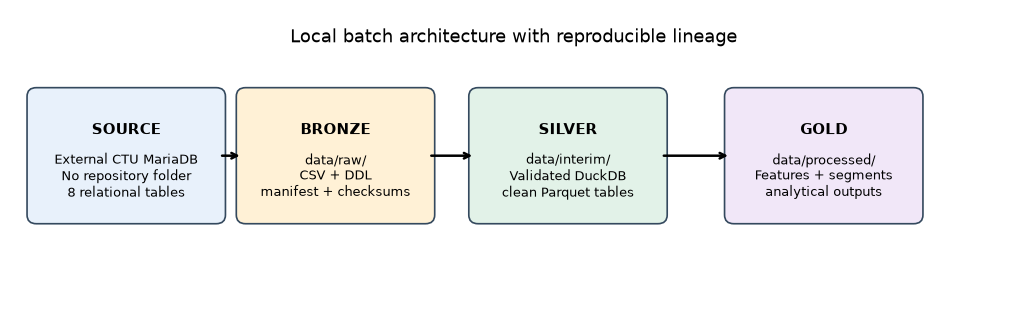

In [9]:
fig, ax = plt.subplots(figsize=(13, 3.8))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.axis("off")

layers = [
    (0.3, "#E8F1FB", "SOURCE", "External CTU MariaDB\nNo repository folder\n8 relational tables"),
    (3.0, "#FFF1D6", "BRONZE", "data/raw/\nCSV + DDL\nmanifest + checksums"),
    (6.0, "#E2F2E8", "SILVER", "data/interim/\nValidated DuckDB\nclean Parquet tables"),
    (9.3, "#F1E7F8", "GOLD", "data/processed/\nFeatures + segments\nanalytical outputs"),
]

for x, color, title, detail in layers:
    box = FancyBboxPatch(
        (x, 1.15),
        2.4,
        1.7,
        boxstyle="round,pad=0.08,rounding_size=0.12",
        facecolor=color,
        edgecolor="#34495E",
        linewidth=1.2,
    )
    ax.add_patch(box)
    ax.text(x + 1.2, 2.35, title, ha="center", va="center", fontsize=11, weight="bold")
    ax.text(x + 1.2, 1.72, detail, ha="center", va="center", fontsize=9)

for start, end in [(2.7, 3.0), (5.4, 6.0), (8.4, 9.3)]:
    ax.annotate("", xy=(end, 2.0), xytext=(start, 2.0), arrowprops={"arrowstyle": "->", "lw": 1.8})

ax.text(6.5, 3.55, "Local batch architecture with reproducible lineage", ha="center", fontsize=13)
plt.show()


## 6. Build the Silver analytical tables

Four outputs are produced at explicit grains:

| Output | Grain | Purpose |
|---|---|---|
| transactions_clean.parquet | Transaction | Standardized transaction analysis |
| accounts_clients.parquet | Client–account disposition | Ownership and authorized-user relationships |
| loans_clean.parquet | Loan | Interpretable loan status and future bounded modelling |
| account_analytical_base.parquet | Account | One-row-per-account base for behavioral feature engineering |

Source columns are preserved or renamed transparently. Standardized labels are added rather than overwriting raw categorical values.


In [10]:
TRANSACTIONS_SQL = """
SELECT
    trans_id,
    account_id,
    date AS transaction_date,
    YEAR(date) AS transaction_year,
    MONTH(date) AS transaction_month_number,
    STRFTIME(date, '%Y-%m') AS transaction_month,
    type AS transaction_type_raw,
    CASE type
        WHEN 'PRIJEM' THEN 'inflow'
        WHEN 'VYDAJ' THEN 'outflow'
        WHEN 'VYBER' THEN 'outflow'
    END AS transaction_direction,
    operation AS operation_raw,
    CASE operation
        WHEN 'VYBER KARTOU' THEN 'card_withdrawal'
        WHEN 'VKLAD' THEN 'cash_deposit'
        WHEN 'PREVOD Z UCTU' THEN 'incoming_transfer'
        WHEN 'VYBER' THEN 'cash_withdrawal'
        WHEN 'PREVOD NA UCET' THEN 'outgoing_transfer'
        ELSE NULL
    END AS operation,
    k_symbol AS purpose_raw,
    CASE NULLIF(TRIM(k_symbol), '')
        WHEN 'POJISTNE' THEN 'insurance'
        WHEN 'SLUZBY' THEN 'statement_fee'
        WHEN 'UROK' THEN 'interest_credit'
        WHEN 'SANKC. UROK' THEN 'penalty_interest'
        WHEN 'SIPO' THEN 'household_payment'
        WHEN 'DUCHOD' THEN 'pension'
        WHEN 'UVER' THEN 'loan_payment'
        ELSE 'unspecified'
    END AS transaction_purpose,
    amount,
    CASE WHEN type = 'PRIJEM' THEN amount ELSE -amount END AS signed_amount,
    balance,
    bank AS counterparty_bank,
    account AS counterparty_account
FROM trans
"""

ACCOUNTS_CLIENTS_SQL = """
WITH card_by_disposition AS (
    SELECT
        disp_id,
        COUNT(*) AS card_count,
        MIN(issued) AS first_card_issued,
        STRING_AGG(DISTINCT type, ', ' ORDER BY type) AS card_types
    FROM card
    GROUP BY disp_id
)
SELECT
    a.account_id,
    a.district_id AS account_district_id,
    a.frequency AS statement_frequency_raw,
    CASE a.frequency
        WHEN 'POPLATEK MESICNE' THEN 'monthly'
        WHEN 'POPLATEK TYDNE' THEN 'weekly'
        WHEN 'POPLATEK PO OBRATU' THEN 'after_transaction'
    END AS statement_frequency,
    a.date AS account_open_date,
    d.disp_id,
    d.type AS relationship_type,
    c.client_id,
    c.gender,
    c.birth_date,
    c.district_id AS client_district_id,
    COALESCE(cb.card_count, 0) AS card_count,
    cb.first_card_issued,
    cb.card_types
FROM account AS a
JOIN disp AS d USING (account_id)
JOIN client AS c USING (client_id)
LEFT JOIN card_by_disposition AS cb USING (disp_id)
"""

LOANS_SQL = """
SELECT
    loan_id,
    account_id,
    date AS loan_date,
    amount AS loan_amount,
    duration AS duration_months,
    payments AS monthly_payment,
    status AS loan_status_raw,
    CASE status
        WHEN 'A' THEN 'completed_no_problems'
        WHEN 'B' THEN 'completed_with_problems'
        WHEN 'C' THEN 'active_no_problems'
        WHEN 'D' THEN 'active_with_problems'
    END AS loan_status,
    status IN ('A', 'B') AS is_completed,
    CASE
        WHEN status = 'A' THEN FALSE
        WHEN status = 'B' THEN TRUE
        ELSE NULL
    END AS completed_repayment_problem
FROM loan
"""

ACCOUNT_BASE_SQL = """
WITH owner AS (
    SELECT
        d.account_id,
        c.client_id AS owner_client_id,
        c.gender AS owner_gender,
        c.birth_date AS owner_birth_date,
        c.district_id AS owner_district_id
    FROM disp AS d
    JOIN client AS c USING (client_id)
    WHERE d.type = 'OWNER'
),
relationship_summary AS (
    SELECT
        account_id,
        COUNT(*) AS client_count,
        COUNT(*) FILTER (WHERE type = 'DISPONENT') AS disponent_count
    FROM disp
    GROUP BY account_id
),
card_summary AS (
    SELECT
        d.account_id,
        COUNT(*) AS card_count,
        MIN(c.issued) AS first_card_issued,
        STRING_AGG(DISTINCT c.type, ', ' ORDER BY c.type) AS card_types
    FROM disp AS d
    JOIN card AS c USING (disp_id)
    GROUP BY d.account_id
),
loan_summary AS (
    SELECT account_id, COUNT(*) AS loan_count
    FROM loan
    GROUP BY account_id
),
order_summary AS (
    SELECT
        account_id,
        COUNT(*) AS standing_order_count,
        SUM(amount) AS standing_order_total_amount
    FROM "order"
    GROUP BY account_id
),
transaction_summary AS (
    SELECT
        account_id,
        COUNT(*) AS transaction_count,
        MIN(date) AS first_transaction_date,
        MAX(date) AS last_transaction_date
    FROM trans
    GROUP BY account_id
)
SELECT
    a.account_id,
    a.district_id AS account_district_id,
    dist.A2 AS account_district_name,
    dist.A3 AS account_region,
    dist.A4 AS district_inhabitants,
    dist.A10 AS district_urbanization_pct,
    dist.A11 AS district_average_salary,
    dist.A12 AS district_unemployment_1995,
    dist.A13 AS district_unemployment_1996,
    dist.A14 AS district_entrepreneurs_per_1000,
    dist.A15 AS district_crimes_1995,
    dist.A16 AS district_crimes_1996,
    a.frequency AS statement_frequency_raw,
    CASE a.frequency
        WHEN 'POPLATEK MESICNE' THEN 'monthly'
        WHEN 'POPLATEK TYDNE' THEN 'weekly'
        WHEN 'POPLATEK PO OBRATU' THEN 'after_transaction'
    END AS statement_frequency,
    a.date AS account_open_date,
    o.owner_client_id,
    o.owner_gender,
    o.owner_birth_date,
    o.owner_district_id,
    rs.client_count,
    rs.disponent_count,
    rs.disponent_count > 0 AS has_disponent,
    COALESCE(cs.card_count, 0) AS card_count,
    COALESCE(cs.card_count, 0) > 0 AS has_card,
    cs.first_card_issued,
    cs.card_types,
    COALESCE(ls.loan_count, 0) AS loan_count,
    COALESCE(ls.loan_count, 0) > 0 AS has_loan,
    COALESCE(os.standing_order_count, 0) AS standing_order_count,
    COALESCE(os.standing_order_count, 0) > 0 AS has_standing_order,
    COALESCE(os.standing_order_total_amount, 0) AS standing_order_total_amount,
    ts.transaction_count,
    ts.first_transaction_date,
    ts.last_transaction_date
FROM account AS a
JOIN district AS dist USING (district_id)
JOIN owner AS o USING (account_id)
JOIN relationship_summary AS rs USING (account_id)
LEFT JOIN card_summary AS cs USING (account_id)
LEFT JOIN loan_summary AS ls USING (account_id)
LEFT JOIN order_summary AS os USING (account_id)
JOIN transaction_summary AS ts USING (account_id)
"""

silver_outputs = {
    "transactions_clean.parquet": TRANSACTIONS_SQL,
    "accounts_clients.parquet": ACCOUNTS_CLIENTS_SQL,
    "loans_clean.parquet": LOANS_SQL,
    "account_analytical_base.parquet": ACCOUNT_BASE_SQL,
}


def sql_literal(path: Path) -> str:
    return "'" + str(path).replace("'", "''") + "'"


for filename, query in silver_outputs.items():
    output_path = INTERIM_DIR / filename
    connection.execute(
        "COPY (" + query.strip().rstrip(";") + ") TO "
        + sql_literal(output_path)
        + " (FORMAT PARQUET, COMPRESSION ZSTD)"
    )
    print("Wrote", output_path.relative_to(PROJECT_ROOT))


Wrote data/interim/transactions_clean.parquet
Wrote data/interim/accounts_clients.parquet
Wrote data/interim/loans_clean.parquet
Wrote data/interim/account_analytical_base.parquet


In [11]:
expected_rows = {
    "transactions_clean.parquet": manifest["tables"]["trans"]["source_row_count"],
    "accounts_clients.parquet": manifest["tables"]["disp"]["source_row_count"],
    "loans_clean.parquet": manifest["tables"]["loan"]["source_row_count"],
    "account_analytical_base.parquet": manifest["tables"]["account"]["source_row_count"],
}
primary_keys = {
    "transactions_clean.parquet": ["trans_id"],
    "accounts_clients.parquet": ["disp_id"],
    "loans_clean.parquet": ["loan_id"],
    "account_analytical_base.parquet": ["account_id"],
}

validation_rows = []
for filename, expected_count in expected_rows.items():
    path = INTERIM_DIR / filename
    actual_count = connection.execute(
        "SELECT COUNT(*) FROM read_parquet(" + sql_literal(path) + ")"
    ).fetchone()[0]
    key_expression = ", ".join('"' + key + '"' for key in primary_keys[filename])
    duplicate_keys = connection.execute(
        "SELECT COUNT(*) FROM (SELECT "
        + key_expression
        + ", COUNT(*) AS n FROM read_parquet("
        + sql_literal(path)
        + ") GROUP BY "
        + key_expression
        + " HAVING COUNT(*) > 1)"
    ).fetchone()[0]

    validation_rows.append(
        {
            "output": filename,
            "expected_rows": expected_count,
            "actual_rows": actual_count,
            "duplicate_keys": duplicate_keys,
            "size_mb": round(path.stat().st_size / 1_048_576, 3),
            "valid": actual_count == expected_count and duplicate_keys == 0,
        }
    )

output_validation = pd.DataFrame(validation_rows)
display(output_validation)
assert output_validation["valid"].all()

transaction_mapping_validation = connection.execute(
    "SELECT "
    "COUNT(*) FILTER (WHERE transaction_direction IS NULL) AS unmapped_directions, "
    "COUNT(*) FILTER (WHERE transaction_purpose IS NULL) AS null_standardized_purpose "
    "FROM read_parquet(" + sql_literal(INTERIM_DIR / "transactions_clean.parquet") + ")"
).fetchdf()
display(transaction_mapping_validation)
assert transaction_mapping_validation.loc[0, "unmapped_directions"] == 0
assert transaction_mapping_validation.loc[0, "null_standardized_purpose"] == 0


,output,expected_rows,actual_rows,duplicate_keys,size_mb,valid
0,transactions_clean.parquet,1056320,1056320,0,7.636,True
1,accounts_clients.parquet,5369,5369,0,0.065,True
2,loans_clean.parquet,682,682,0,0.010,True
3,account_analytical_base.parquet,4500,4500,0,0.121,True


,unmapped_directions,null_standardized_purpose
0,0,0


## 7. Foundation findings and handoff

- The snapshot contains eight relational tables, 1,079,680 total rows, and 1,056,320 transactions covering 1993–1998.
- All source, export, and local row counts match.
- All eight declared foreign-key relationships contain zero orphaned rows.
- Primary keys are complete and unique.
- Every account has one owner; 869 accounts have an additional authorized disposition.
- Missing transaction fields are largely structural. Two district statistics are missing for one district and remain null.
- Transaction amounts are non-negative, while negative balances occur and are retained as valid financial states.
- Original Czech codes are preserved alongside validated English analytical labels.
- Four purpose-specific Silver tables have been created and validated.

**Next notebook:** `02_behavioral_and_temporal_analysis.ipynb` will perform EDA, construct behavioral features, analyze temporal patterns, and prepare association-rule inputs. It will read the Silver Parquet outputs created here rather than repeat ingestion or cleaning.
